# Active Model B 1D — CNEEP_1D Notebook

In [ ]:
import sys
import os

CNEEP_V2_ROOT = os.path.abspath('/home/user1/CNEEP_v2')

if CNEEP_V2_ROOT not in sys.path:
    sys.path.append(CNEEP_V2_ROOT)

In [ ]:
sys.path.append(CNEEP_V2_ROOT)
sys.path.append(os.path.join(CNEEP_V2_ROOT, 'data', 'AMB'))
sys.path.append(os.path.join(CNEEP_V2_ROOT, 'utils'))
sys.path.append(os.path.join(CNEEP_V2_ROOT, 'models'))

from argparse import Namespace
import numpy as np
import torch
from datetime import datetime
from utils.sampler import CartesianSeqSampler
from models.train_1d import train_1d as train
from models.validate_1d import validate_1d as validate
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from generate_trajectories_1d import ActiveModelB1D


In [ ]:
#
# Hyper parameters
#
opt = Namespace()

# dataset parameter
n_trajs = 1000
n_steps = 1000
burn_in = 10000
skip      = 1
opt.device = "cuda" if torch.cuda.is_available() else "cpu"


# alpha-NEEP
opt.alpha     = -0.5
opt.lam       = 0.0
opt.threshold = 0.01

opt.positional  = False
opt.latent_size = 10

# training
opt.n_iter           = 2000
opt.train_batch_size = 4096
opt.test_batch_size  = 4096
opt.video_batch_size = 256
opt.lr               = 1e-3
opt.wd               = 1e-3
opt.scalar           = 1
opt.input_scalar     = 1
opt.loss_scalar      = 1e2
opt.clip_norm        = 1

opt.record_freq = 1000
opt.seed        = 3

# dataset / model architecture
opt.n_layer     = 2
opt.n_channel   = 32
opt.input_shape = (256,)    # AMB grid size
opt.M           = n_trajs           # single trajectory
opt.L           = n_steps
opt.M_test      = 1
opt.L_test      = 10000
opt.seq_len     = 2
opt.val_ratio   = 0.2
opt.time_step   = 0.01       # dt

# AMB model parameters
import torch
kwargs = {
    'Lx': 256,            # Domain length
    'dx': 1,             # Spatial resolution
    'a': 0.125,            # Active model parameter A
    'b': 0.125,            # Active model parameter B
    'kappa': 8.0,          # Gradient coefficient
    'lam': 5.0,            # Active parameter (Lambda)
    'D': 0.1,            # Noise strength (Diffusivity)
    'dt': 0.01,           # Time step
    'smooth': True,        # Smoothing for stability
    'backend': 'torch',
    'use_gpu': torch.cuda.is_available(),
    'bc': "periodic"
}

print(f"Using Backend: {kwargs['backend']} | GPU Enabled: {kwargs['use_gpu']}")

torch.manual_seed(opt.seed)

#
# results folder
#
result_folder = os.path.join(CNEEP_V2_ROOT, 'results')
current_result_folder = os.path.join(
    result_folder, f"AMB-{datetime.now().strftime('%Y-%m-%d-%H%M%S')}")
os.makedirs(current_result_folder, exist_ok=True)
current_checkpoint_path = os.path.join(current_result_folder, 'model_parameter.pth.tar')

print(f"Device: {opt.device}")
print(f"Results: {current_result_folder}")

Using Backend: torch | GPU Enabled: True
Device: cuda
Results: /home/user1/CNEEP_v2/results/AMB-2026-03-13-062929


## 1. Generate AMB trajectory (train)

In [ ]:
train_seed = 42
np.random.seed(train_seed)
if kwargs['backend'] == 'torch':
    torch.manual_seed(train_seed)

model_amb = ActiveModelB1D(**kwargs)

print(f"[INFO] Generating TRAIN trajectory (n_trajs={n_trajs}, burn_in={burn_in}, n_steps={n_steps})")
trajectory = model_amb.generate_trajectories(
    n_trajectories=n_trajs, n_steps=n_steps, burn_in=burn_in
)
print(f"[INFO] Trajectory shape: {trajectory.shape}")

traj_train = trajectory   # skip=1, no subsampling
opt.M = traj_train.shape[0]
opt.L = traj_train.shape[1]
print(f"[INFO] Train data: {traj_train.shape}  (M={opt.M}, L={opt.L})")

[INFO] Generating TRAIN trajectory (n_seeds=1000, burn_in=10000, n_steps=1000)


Generating Trajectories: 100%|████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2922.72it/s]


[INFO] Trajectory shape: (1000, 1000, 512)
[INFO] Train data: (1000, 1000, 512)  (M=1000, L=1000)


In [ ]:
#
# Ground truth EPR (train data)
#
print("[INFO] Computing GT EPR time series on TRAIN data ...")
train_total_epr = np.zeros(opt.L - 1)
train_epr_maps  = np.zeros((opt.L - 1, kwargs["Lx"]))

for t in tqdm(range(opt.L - 1)):
    train_epr_map = model_amb.compute_local_epr_density(torch.tensor(traj_train[:, t]).to(opt.device), torch.tensor(traj_train[:,t+1]).to(opt.device))
    # Ensure conversion of the current train_epr_map to numpy
    if hasattr(train_epr_map, 'cpu'):
        train_epr_map = train_epr_map.cpu().numpy()
    train_mean_epr_map = train_epr_map.mean(axis=0)
    train_epr_maps[t] = train_mean_epr_map
    train_total_epr[t] = np.sum(train_mean_epr_map) * model_amb.dx

train_cumulative = np.cumsum(train_total_epr * model_amb.dt)

print(f"GT mean EPR: {train_total_epr.mean():.6e}")
print(f"GT cumulative EP (final): {train_cumulative[-1]:.6e}")

[INFO] Computing GT EPR time series on TRAIN data ...


100%|█████████████████████████████████████████████████████████████████████████████████| 999/999 [00:23<00:00, 43.18it/s]

GT mean EPR: 1.449847e+00
GT cumulative EP (final): 1.448398e+01


## 1-b. Generate AMB trajectory (test, different seed)

In [ ]:
test_seed = 123
np.random.seed(test_seed)
if kwargs['backend'] == 'torch':
    torch.manual_seed(test_seed)

model_amb_test = ActiveModelB1D(**kwargs)

test_seeds = opt.M_test
test_steps = opt.L_test

print(f"[INFO] Generating TEST trajectory (n_trajs={test_seeds}, burn_in={burn_in}, n_steps={test_steps})")
trajectory_test = model_amb_test.generate_trajectories(
    n_trajectories=test_seeds, n_steps=test_steps, burn_in=burn_in
)
print(f"[INFO] Test trajectory shape: {trajectory_test.shape}")

traj_test = trajectory_test   # skip=1, no subsampling
opt.M_test = traj_test.shape[0]
opt.L_test = traj_test.shape[1]
print(f"[INFO] Test data: {traj_test.shape}  (M_test={opt.M_test}, L_test={opt.L_test})")

[INFO] Generating TEST trajectory (n_seeds=1, burn_in=10000, n_steps=10000)


Generating Trajectories: 100%|██████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 3409.26it/s]

[INFO] Test trajectory shape: (1, 10000, 512)
[INFO] Test data: (1, 10000, 512)  (M_test=1, L_test=10000)


In [ ]:
#
# Ground truth EPR (test data)
#
print("[INFO] Computing GT EPR time series on TEST data ...")
gt_total_epr = np.zeros(opt.L_test - 1)
gt_epr_maps  = np.zeros((opt.L_test - 1, kwargs["Lx"]))

for t in tqdm(range(opt.L_test - 1)):
    epr_map = model_amb_test.compute_local_epr_density(torch.tensor(traj_test[:, t]).to(opt.device), torch.tensor(traj_test[:,t+1]).to(opt.device))
    if hasattr(epr_map, 'cpu'):
        epr_map = epr_map.cpu().numpy()
    mean_epr_map = epr_map.mean(axis=0)
    gt_epr_maps[t] = mean_epr_map
    gt_total_epr[t] = np.sum(mean_epr_map) * model_amb_test.dx

gt_cumulative = np.cumsum(gt_total_epr * model_amb_test.dt)

print(f"GT mean EPR: {gt_total_epr.mean():.6e}")
print(f"GT cumulative EP (final): {gt_cumulative[-1]:.6e}")

[INFO] Computing GT EPR time series on TEST data ...


100%|█████████████████████████████████████████████████████████████████████████████| 9999/9999 [00:01<00:00, 6840.66it/s]

GT mean EPR: 1.769021e+00
GT cumulative EP (final): 1.768844e+02


## 2. Prepare video tensors (train & test)

In [ ]:
#
# Convert density field to video tensor: (M, L, 1, Lx)
#
train_val_split_idx = int(opt.M * (1 - opt.val_ratio))
M_train_new = train_val_split_idx
M_val = opt.M - M_train_new

traj_train_new = traj_train[:train_val_split_idx]
traj_val = traj_train[train_val_split_idx:]

train_video = torch.from_numpy(traj_train_new).float().to(opt.device)
train_video = train_video.unsqueeze(2)   # (M_train, L, 1, Lx)

val_video = torch.from_numpy(traj_val).float().to(opt.device)
val_video = val_video.unsqueeze(2)       # (M_val, L, 1, Lx)

test_video = torch.from_numpy(traj_test).float().to(opt.device)
test_video = test_video.unsqueeze(2)     # (M_test, L_test, 1, Lx)

# Use training data for normalization
mean = torch.mean(train_video)
std  = torch.std(train_video)
transform = lambda x: (x - mean) * opt.input_scalar / std

print(f"Train video tensor: {train_video.shape}")
print(f"Val video tensor:   {val_video.shape}")
print(f"Test video tensor:  {test_video.shape}")
print(f"Mean: {mean:.4f}, Std: {std:.4f}")

Train video tensor: torch.Size([1000, 1000, 1, 512])
Test video tensor:  torch.Size([1, 10000, 1, 512])
Mean: -0.0000, Std: 0.9676


## 3. Build and train model

In [ ]:
from models.UNEEP_1D import CNEEP
from torch.optim.lr_scheduler import ReduceLROnPlateau

model = CNEEP(opt)
model = model.to(opt.device)
optim = torch.optim.Adam(model.parameters(), opt.lr, weight_decay=opt.wd)

train_sampler = CartesianSeqSampler(
    M_train_new, opt.L, opt.seq_len, opt.train_batch_size, device=opt.device)
val_sampler = CartesianSeqSampler(
    M_val, opt.L, opt.seq_len, opt.test_batch_size, device=opt.device, train=False)
test_sampler  = CartesianSeqSampler(
    opt.M_test, opt.L_test, opt.seq_len, opt.test_batch_size, device=opt.device, train=False)

print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

Model params: 388,705


In [ ]:
# use saved one
# model.load_state_dict(
#     torch.load('drive/MyDrive/CNEEP_v2/results/AMB-2026-03-07-033430')['state_dict'])
model.load_state_dict(
    torch.load('CNEEP_v2/results/AMB-2026-03-11-064117/model_parameter.pth.tar')['state_dict'])

<All keys matched successfully>

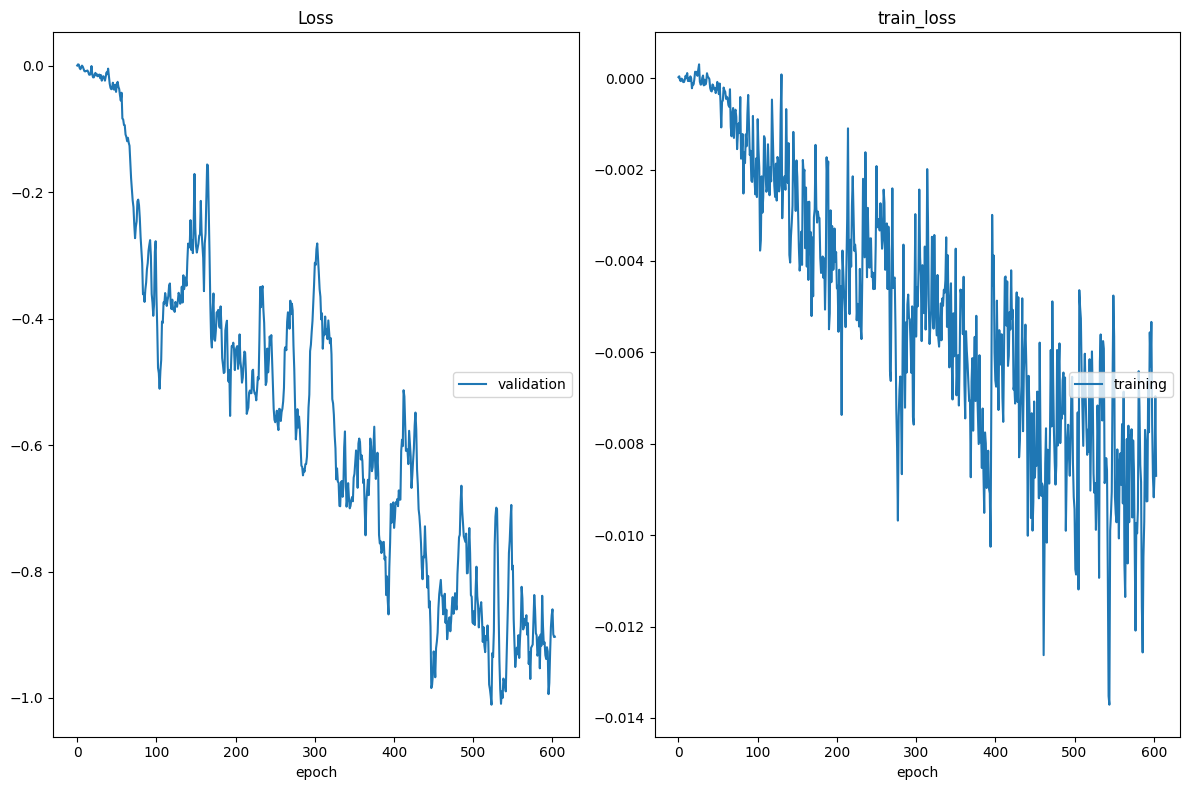


 20%|███████████████▋                                                              | 604/3000 [43:14<2:51:26,  4.29s/it]

Loss
	validation       	 (min:   -1.011, max:    0.002, cur:   -0.903)
train_loss
	training         	 (min:   -0.014, max:    0.000, cur:   -0.009)


In [ ]:
#
# Training loop
#
# !pip install livelossplot
from livelossplot import PlotLosses
smoothing = 0.5


In [ ]:

liveloss = PlotLosses()

smooth_train_loss = None
smooth_valid_loss = None
train_losses = []
R_values     = []
valid_losses = []
best_valid_loss = float('inf')

for i in tqdm(range(1, opt.n_iter + 1)):
    train_loss, R_value = train(
        opt, model, optim, train_video, train_sampler, transform)
    train_losses.append(train_loss)
    R_values.append(R_value)

    _, _, valid_loss = validate(
        opt, model, val_video, val_sampler, transform)
    valid_losses.append(valid_loss)

    # live train loss
    if smooth_train_loss is None or smooth_valid_loss is None:
        smooth_train_loss = train_loss
        smooth_valid_loss = valid_loss
    else:
        smooth_train_loss = smoothing * smooth_train_loss + (1 - smoothing) * train_loss
        smooth_valid_loss = smoothing * smooth_valid_loss + (1 - smoothing) * valid_loss

    liveloss.update({'train_loss': smooth_train_loss, 'val_loss': smooth_valid_loss})
    liveloss.send()

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        state = {
            'epoch': i,
            'settings': opt.__dict__,
            'state_dict': model.state_dict(),
            'optimizer': optim.state_dict(),
        }
        torch.save(state, current_checkpoint_path)

# model.load_state_dict(
#     torch.load(current_checkpoint_path)['state_dict'])

In [ ]:
print(current_checkpoint_path)

/home/user1/CNEEP_v2/results/AMB-2026-03-13-062929/model_parameter.pth.tar


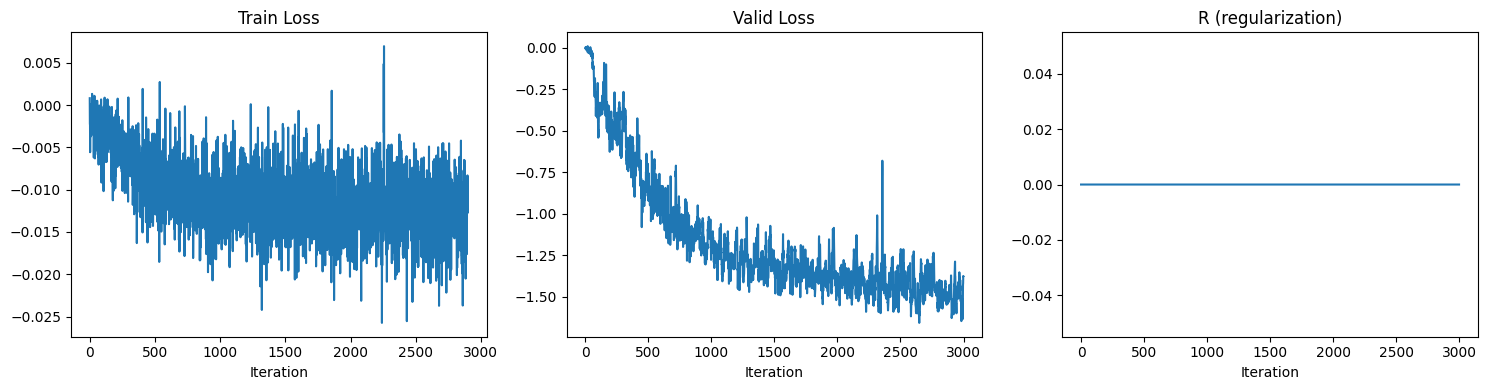

In [ ]:
#
# Training curves
#
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].plot(train_losses[100:]); axes[0].set_title('Train Loss')
axes[1].plot(valid_losses); axes[1].set_title('Valid Loss')
# axes[2].plot(R_values);     axes[2].set_title('R (regularization)')
for ax in axes: ax.set_xlabel('Iteration')
plt.tight_layout()
plt.savefig(f'{current_result_folder}/training_curves.png', dpi=150)
plt.show()

## 4. Validation — predicted EP

In [13]:
#
# Full-trajectory validation (on TEST data)
#
full_sampler = CartesianSeqSampler(
    opt.M_test, opt.L_test,  opt.seq_len, opt.video_batch_size,
    device=opt.device, train=False)

pred_ent, pred_maps, _ = validate(
    opt, model, test_video, full_sampler, transform)

pred_maps = pred_maps / (kwargs['Lx'] * kwargs['dt'])
pred_scalar = pred_ent.flatten() / kwargs['dt']       # (L_test-1,) predicted EP per transition
pred_cumulative = np.cumsum(pred_scalar * kwargs['dt'])

print(f"Pred mean EP: {pred_scalar.mean():.6e}")
print(f"Pred cumulative EP (final): {pred_cumulative[-1]:.6e}")

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
print(test_video.shape)
print(gt_epr_maps.shape)
print(pred_maps.shape)

torch.Size([10, 1000, 1, 512])
(999, 512)
(9990, 512)


## 5. EPR time series: GT vs Predicted

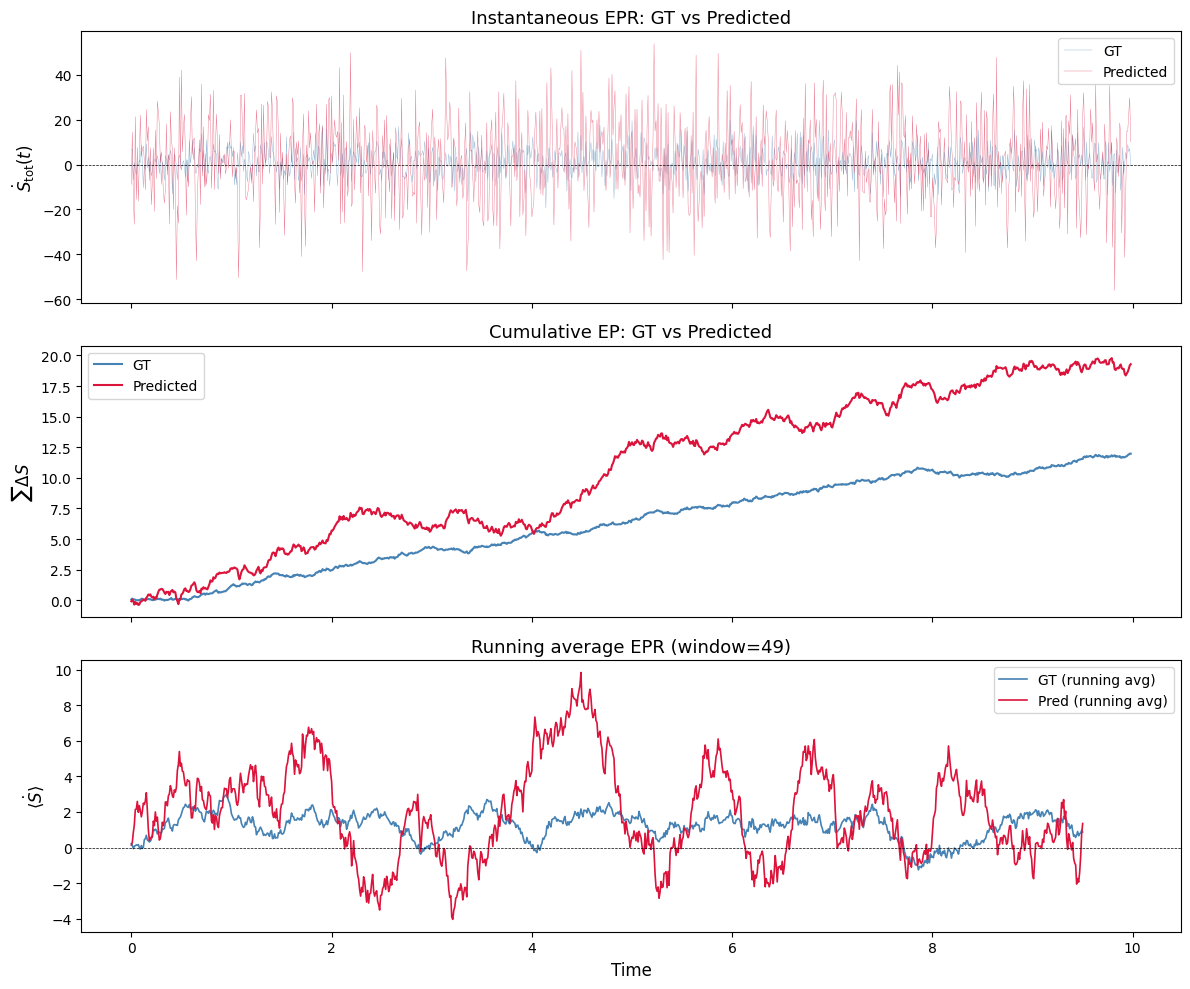

GT  mean EPR:   1.198337e+00
Pred mean EPR:  1.930427e+00
Ratio (pred/GT): 1.6109


In [ ]:
#
# GT EPR vs Predicted EPR time series comparison
#
min_len = min(len(gt_total_epr), len(pred_scalar))
dt_eff  = kwargs['dt']
time_axis = np.arange(min_len) * dt_eff

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# (a) Instantaneous EPR
axes[0].plot(time_axis, gt_total_epr[:min_len],
             lw=0.3, alpha=0.6, color='steelblue', label='GT')
axes[0].plot(time_axis, pred_scalar[:min_len],
             lw=0.3, alpha=0.6, color='crimson', label='Predicted')
axes[0].set_ylabel(r'$\dot{S}_{\mathrm{tot}}(t)$', fontsize=12)
axes[0].set_title('Instantaneous EPR: GT vs Predicted', fontsize=13)
axes[0].legend(loc='upper right')
axes[0].axhline(0, color='k', lw=0.5, ls='--')

# (b) Cumulative EP
gt_cum  = np.cumsum(gt_total_epr[:min_len] * kwargs['dt'])
pred_cum = np.cumsum(pred_scalar[:min_len] * kwargs['dt'])
axes[1].plot(time_axis, gt_cum, lw=1.5, color='steelblue', label='GT')
axes[1].plot(time_axis, pred_cum, lw=1.5, color='crimson', label='Predicted')
axes[1].set_ylabel(r'$\sum \Delta S$', fontsize=12)
axes[1].set_title('Cumulative EP: GT vs Predicted', fontsize=13)
axes[1].legend(loc='upper left')

# (c) Running average EPR
window = max(min_len // 20, 1)
gt_running  = np.convolve(gt_total_epr[:min_len],
                          np.ones(window)/window, mode='valid')
pred_running = np.convolve(pred_scalar[:min_len],
                           np.ones(window)/window, mode='valid')
t_run = time_axis[:len(gt_running)]
axes[2].plot(t_run, gt_running, lw=1.2, color='steelblue', label='GT (running avg)')
axes[2].plot(t_run, pred_running, lw=1.2, color='crimson', label='Pred (running avg)')
axes[2].set_ylabel(r'$\langle \dot{S} \rangle$', fontsize=12)
axes[2].set_xlabel('Time', fontsize=12)
axes[2].set_title(f'Running average EPR (window={window})', fontsize=13)
axes[2].legend(loc='upper right')
axes[2].axhline(0, color='k', lw=0.5, ls='--')

fig.tight_layout()
fig.savefig(f'{current_result_folder}/epr_gt_vs_pred.png', dpi=150)
plt.show()

print(f"GT  mean EPR:   {gt_total_epr[:min_len].mean():.6e}")
print(f"Pred mean EPR:  {pred_scalar[:min_len].mean():.6e}")
print(f"Ratio (pred/GT): {pred_scalar[:min_len].mean() / (gt_total_epr[:min_len].mean() + 1e-20):.4f}")

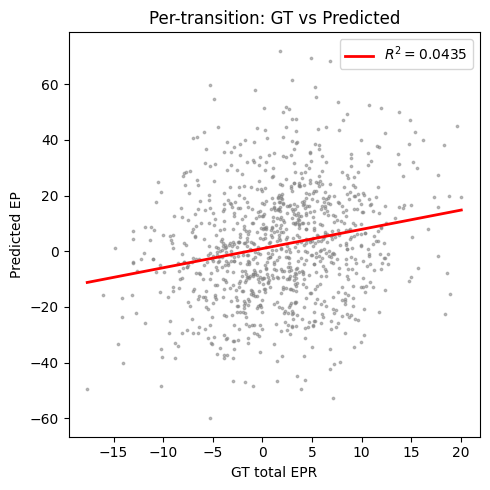

R² = 0.043499


In [ ]:
#
# Scatter plot: GT vs Predicted (per-transition)
#
from scipy import stats

gt_flat   = gt_total_epr[:min_len]
pred_flat = pred_scalar[:min_len]

slope, intercept, r_value, _, _ = stats.linregress(gt_flat, pred_flat)

plt.figure(figsize=(5, 5), dpi=100)
plt.scatter(gt_flat, pred_flat, alpha=0.5, s=3, color='grey', rasterized=True)
x_line = np.linspace(gt_flat.min(), gt_flat.max(), 100)
plt.plot(x_line, slope * x_line + intercept, 'r-', lw=2,
         label=f'$R^2 = {r_value**2:.4f}$')
plt.xlabel('GT total EPR')
plt.ylabel('Predicted EP')
plt.legend()
plt.title('Per-transition: GT vs Predicted')
plt.tight_layout()
plt.savefig(f'{current_result_folder}/scatter_gt_vs_pred.png', dpi=150)
plt.show()
print(f'R² = {r_value**2:.6f}')

## 6. Mean EPR density map: GT vs Predicted

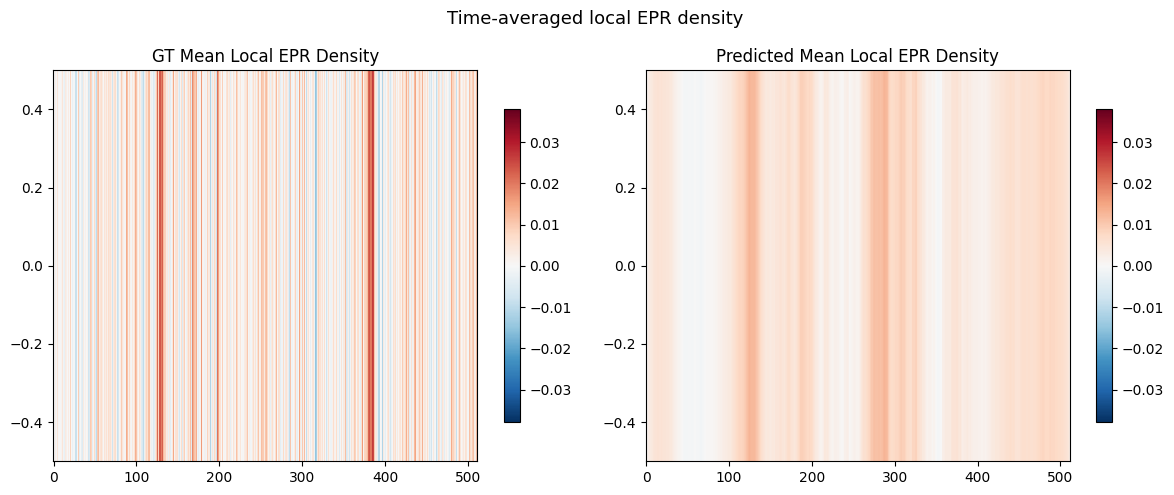

In [ ]:
#
# Mean local EPR density: GT vs Predicted
#
gt_mean_map   = gt_epr_maps[:min_len].mean(axis=0)
pred_mean_map = pred_maps[:min_len].mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
x_axis = np.arange(len(gt_mean_map)) * kwargs['dx']

ax.plot(x_axis, gt_mean_map, label='GT', color='blue')
ax.plot(x_axis, pred_mean_map, label='Predicted', color='red', linestyle='--')

ax.set_xlabel('Position (x)')
ax.set_ylabel(r'$\langle\sigma\rangle$')
ax.set_title('Time-averaged local EPR density: GT vs Predicted')
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f'{current_result_folder}/mean_epr_map_comparison.png', dpi=150)
plt.show()

## 7. EPR map animation

In [ ]:
#
# Overlay animation: density field + predicted EP map
#
n_frames = min_len # Animate for all available time steps (L_test - 1)

# Use the first trajectory for density visualization
density_for_animation = traj_test[0, :n_frames, :] # (n_frames, Lx)

pred_map_norm_subset = (pred_maps[:n_frames] - pred_maps[:n_frames].min()) / \
                (pred_maps[:n_frames].max() - pred_maps[:n_frames].min() + 1e-8)

fig, ax = plt.subplots(figsize=(10, 5)) # Make it wider for 512 pixels

# Display initial frame
im  = ax.imshow(density_for_animation[0].reshape(1, -1), cmap='gray', animated=True,
                origin='lower', interpolation='nearest', aspect=20) # Increased aspect to 20
ov  = ax.imshow(pred_map_norm_subset[0].reshape(1, -1), cmap='bwr', alpha=0.5,
                animated=True, origin='lower', interpolation='nearest', aspect=20) # Increased aspect to 20
ax.set_yticks([]) # Hide y-ticks as it's a single row
ax.set_xticks([]) # Hide x-ticks for a cleaner look

def update(frame):
    im.set_array(density_for_animation[frame].reshape(1, -1))
    ov.set_array(pred_map_norm_subset[frame].reshape(1, -1))
    ax.set_title(f'Time Step: {frame}') # Add time step to title
    return [im, ov, ax.title] # Return the title object too for blitting

ani = FuncAnimation(fig, update, frames=n_frames, blit=True)
ani.save(f'{current_result_folder}/epr_overlay.gif', fps=10)
plt.close()
print(f'Animation saved ({n_frames} frames)')

MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved (999 frames)


## Updated EPR map animation

In [ ]:
from IPython.display import Image
Image(filename=f'{current_result_folder}/epr_overlay.gif')

Output hidden; open in https://colab.research.google.com to view.

## 8. PCA of latent space

In [ ]:
latent_results = []
hooks = []

def hook_latent(module, input, output):
    latent_results.append(output.cpu().detach().numpy())

hooks.append(
    model._modules.get('latent')
    .register_forward_hook(hook_latent)
)

pca_sampler = CartesianSeqSampler(
    1, opt.L_test, opt.seq_len, opt.video_batch_size,
    device=opt.device, train=False)
_ = validate(opt, model, test_video, pca_sampler, transform)

for h in hooks:
    h.remove()

if latent_results:
    lv = latent_results[0] - np.mean(latent_results[0], axis=0)
    std_lv = np.std(lv, axis=0)
    std_lv[std_lv < 1e-8] = 1.0
    lv = lv / std_lv

    U, S, V = torch.pca_lowrank(torch.tensor(lv), q=opt.latent_size)

    plt.figure(figsize=(5, 5), dpi=100)
    colors = U[:, 2] if U.shape[1] > 2 else U[:, 0]
    colors = (colors - colors.mean()) / (colors.std() + 1e-8)
    plt.scatter(U[:, 0], U[:, 1], c=colors, cmap='viridis', s=5, alpha=0.5)
    plt.colorbar()
    plt.title('PCA of Latent Space')
    plt.xlabel('PC 1'); plt.ylabel('PC 2')
    plt.tight_layout()
    plt.savefig(f'{current_result_folder}/PCA_scatter.png', dpi=150)
    plt.show()

    np.set_printoptions(precision=2, suppress=True)
    print(f'Singular values: {S.numpy()}')
else:
    print('No latent vectors captured')